# Pull World Bank WDI indicators
This notebook downloads and caches the selected WDI indicators, builds
quinquennial extracts, and records coverage metadata for each indicator.

In [1]:
from __future__ import annotations

import json
import sys
from functools import reduce
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.io_worldbank import (
    fetch_country_metadata,
    fetch_indicator_metadata,
    fetch_wdi_indicator,
)
from src.paths import INTERMEDIATE_DIR, LOGS_DIR, OUTPUT_DIR, QUINQUENNIAL_YEARS, RAW_DIR
from src.viz_style import savefig, set_style

In [2]:
set_style()
config_path = Path(LOGS_DIR) / "run_config.json"
if not config_path.exists():
    raise FileNotFoundError("Missing run config. Run 00_env_setup first.")

config = json.loads(config_path.read_text())
indicators = config["wdi_indicators"]

In [3]:
cache_dir = RAW_DIR / "wdi_cache"
annual_frames = []
quin_frames = []
metadata = {}
coverage_rows = []

for code, spec in indicators.items():
    df = fetch_wdi_indicator(code, cache_dir)
    name = spec["name"]
    df = df.rename(columns={"value": name})

    annual_frames.append(df)
    df_q = df[df["year"].isin(QUINQUENNIAL_YEARS)].copy()
    quin_frames.append(df_q)

    coverage = df_q.groupby("year")[name].apply(lambda series: series.notna().sum())
    coverage_rows.append(coverage.rename(name))

    meta = fetch_indicator_metadata(code, RAW_DIR / "world_bank")
    meta.update({
        "short_name": name,
        "label": spec.get("label"),
        "transform": spec.get("transform"),
        "coverage_by_year": coverage.to_dict(),
        "coverage_total": int(df_q[name].notna().sum()),
    })
    metadata[name] = meta

In [4]:
annual = reduce(
    lambda left, right: left.merge(right, on=["iso3c", "year"], how="outer"),
    annual_frames,
)
annual_path = INTERMEDIATE_DIR / "wdi_annual_selected.parquet"
annual.to_parquet(annual_path, index=False)

quin = reduce(
    lambda left, right: left.merge(right, on=["iso3c", "year"], how="outer"),
    quin_frames,
)
quin_path = INTERMEDIATE_DIR / "wdi_quinquennial_selected.parquet"
quin.to_parquet(quin_path, index=False)

In [5]:
coverage_matrix = pd.concat(coverage_rows, axis=1).reset_index().rename(columns={"index": "year"})
coverage_path = OUTPUT_DIR / "tables" / "wdi_coverage_matrix.csv"
coverage_path.parent.mkdir(parents=True, exist_ok=True)
coverage_matrix.to_csv(coverage_path, index=False)
display(coverage_matrix.style.set_caption("WDI quinquennial coverage matrix"))

meta_path = INTERMEDIATE_DIR / "wdi_metadata.json"
meta_path.write_text(json.dumps(metadata, indent=2))

country_meta = fetch_country_metadata(RAW_DIR / "world_bank")
country_meta.to_parquet(INTERMEDIATE_DIR / "country_metadata.parquet", index=False)
display(country_meta.head(10).style.set_caption("Country metadata sample"))

meta_df = (
    pd.DataFrame.from_dict(metadata, orient="index")
    .reset_index()
    .rename(columns={"index": "indicator"})
    .loc[:, ["indicator", "short_name", "label", "transform", "coverage_total"]]
)
display(meta_df.style.set_caption("Indicator metadata summary"))

,year,gdp_pc_const,gdp_growth_ann_pct,inv_share_gdp,inflation_cpi_ann_pct,broad_money_gdp,trade_open_gdp,cab_gdp,tot_index,gov_cons_gdp,tax_rev_gdp,unemp_rate,pop_total,urban_share,priv_credit_gdp
0,1970,179,157,107,107,129,121,12,0,123,0,0,260,261,94
1,1975,184,183,113,122,136,127,53,0,127,52,0,260,261,105
2,1980,200,193,130,130,152,141,116,74,140,54,0,260,261,122
3,1985,208,209,140,150,156,143,126,81,145,58,0,260,261,131
4,1990,236,219,164,169,161,169,131,80,167,86,0,261,261,123
5,1995,239,240,182,197,189,194,143,81,189,99,231,261,261,148
6,2000,243,243,191,206,195,198,148,199,196,98,231,261,261,156
7,2005,247,248,198,220,201,209,173,202,204,128,231,261,261,194
8,2010,254,254,205,231,198,213,185,203,210,158,231,261,261,214
9,2015,256,255,210,232,196,222,188,207,215,179,231,261,261,219


,iso3c,country_name,wb_region,wb_income_group
0,ABW,Aruba,Latin America & Caribbean,High income
1,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
2,AGO,Angola,Sub-Saharan Africa,Lower middle income
3,ALB,Albania,Europe & Central Asia,Upper middle income
4,AND,Andorra,Europe & Central Asia,High income
5,ARE,United Arab Emirates,"Middle East, North Africa, Afghanistan & Pakistan",High income
6,ARG,Argentina,Latin America & Caribbean,Upper middle income
7,ARM,Armenia,Europe & Central Asia,Upper middle income
8,ASM,American Samoa,East Asia & Pacific,High income
9,ATG,Antigua and Barbuda,Latin America & Caribbean,High income


,indicator,short_name,label,transform,coverage_total
0,gdp_pc_const,gdp_pc_const,"GDP per capita, constant",log,2498
1,gdp_growth_ann_pct,gdp_growth_ann_pct,GDP growth (annual %),level,2455
2,inv_share_gdp,inv_share_gdp,Gross capital formation (% GDP),level,1847
3,inflation_cpi_ann_pct,inflation_cpi_ann_pct,"Inflation, CPI (annual %)",level,1985
4,broad_money_gdp,broad_money_gdp,Broad money (% GDP),level,1895
5,trade_open_gdp,trade_open_gdp,Trade (% GDP),level,1958
6,cab_gdp,cab_gdp,Current account balance (% GDP),level,1458
7,tot_index,tot_index,Net barter terms of trade index,level,1333
8,gov_cons_gdp,gov_cons_gdp,Government consumption (% GDP),level,1930
9,tax_rev_gdp,tax_rev_gdp,Tax revenue (% GDP),level,1076


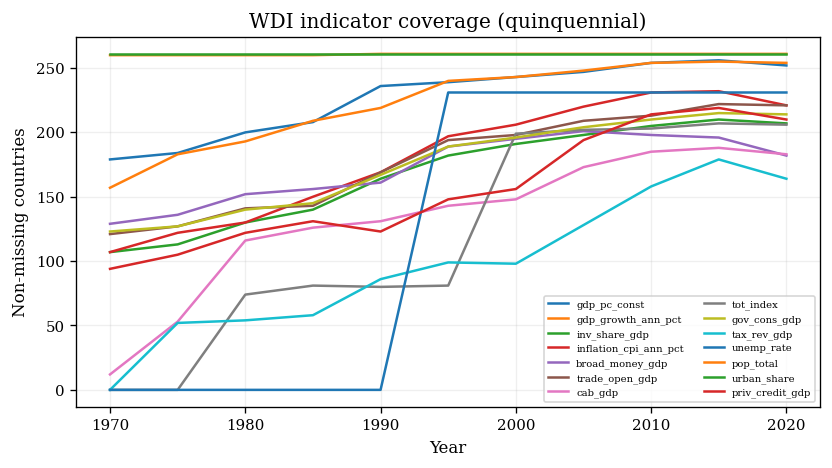

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for col in coverage_matrix.columns:
    if col == "year":
        continue
    ax.plot(coverage_matrix["year"], coverage_matrix[col], label=col)
ax.set_title("WDI indicator coverage (quinquennial)")
ax.set_xlabel("Year")
ax.set_ylabel("Non-missing countries")
ax.legend(fontsize=6, ncol=2)

display(fig)
savefig(fig, OUTPUT_DIR / "figures" / "coverage" / "wdi_coverage_by_year")
plt.close(fig)

## Interpretation
WDI coverage varies across indicators, but the quinquennial matrix shows
consistently higher availability in recent decades. The most complete
series are urban population share, total population, and GDP per capita
(total non-missing counts of 2,871; 2,867; and 2,498 respectively), while
tax revenue (1,076), terms of trade (1,333), and unemployment (1,386) are
the sparsest. These differences guide which indicators can be used for
tighter robustness checks versus exploratory comparisons.